# 01 — Exploratory data analysis

Goal: understand the daily SNS emergency data before modelling it. Questions:

1. How complete is the data, per region?
2. How has the waiting time evolved?
3. What seasonality is there (weekday, month, holidays)?
4. How much do flu and temperature explain?
5. What happened in 2020 (COVID), and how should it be handled?
6. How predictable is the series, and how good is a naive forecast?

The conclusions are summarised at the end. Data comes from `src.data.load_daily()`; see `docs/data-sources.md`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import holidays
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf

from src.data import REGIONS, load_daily

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 1)

daily = load_daily()
national = daily[daily["ars"] == "Portugal Continental"].set_index("periodo").sort_index()
wait = daily.pivot(index="periodo", columns="ars", values="wait_minutes")[REGIONS]
daily.head()

,periodo,ars,admission_pct,episodes,non_urgent_rate,respiratory_pct,wait_minutes,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum
0,2016-11-01,ARS Norte,8.9,5085.0,37.6,7.0,44.8,22.7,15.0,18.0,0.0
1,2016-11-01,ARS Centro,10.9,2889.0,34.1,6.6,39.3,23.0,14.1,18.1,0.5
2,2016-11-01,ARS Lisboa e Vale do Tejo,7.9,5381.0,45.2,6.9,62.1,20.7,17.4,18.7,0.7
3,2016-11-01,ARS Alentejo,9.3,1001.0,39.8,10.2,22.1,22.9,15.3,18.5,0.0
4,2016-11-01,ARS Algarve,7.9,711.0,36.6,6.3,43.9,20.6,18.4,19.4,0.0


## 1. Data completeness

In [2]:
missing = (
    daily.assign(year=daily["periodo"].dt.year)
    .groupby(["ars", "year"])["wait_minutes"]
    .apply(lambda s: s.isna().sum())
    .unstack()
)
missing

year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
ars,,,,,,,,,,,
ARS Alentejo,0,0,0,0,0,0,0,0,0,11,0
ARS Algarve,4,153,8,147,0,0,0,4,100,78,251
ARS Centro,0,0,0,0,0,0,0,0,0,11,0
ARS Lisboa e Vale do Tejo,0,0,0,0,0,0,0,0,0,11,0
ARS Norte,0,0,0,0,0,0,0,0,0,11,0
Portugal Continental,0,0,0,0,0,0,0,0,0,11,0


In [3]:
algarve = wait["ARS Algarve"]
print("Last Algarve waiting time:", algarve.dropna().index.max().date())
print("Days with Algarve data in 2026:", algarve["2026"].notna().sum(), "of", len(algarve["2026"]))

Last Algarve waiting time: 2026-06-14
Days with Algarve data in 2026: 25 of 276


Every region misses the same 11 days (2025-06-24 to 2025-07-04, a publication gap). The **Algarve** is different: it misses
whole blocks in 2017, 2019, 2024 and 2025, and in 2026 it has almost no waiting-time data. The episode counts for the
Algarve, on the other hand, are complete, so the gap is in how the waiting time is reported, not in the activity itself.

## 2. Trend per region

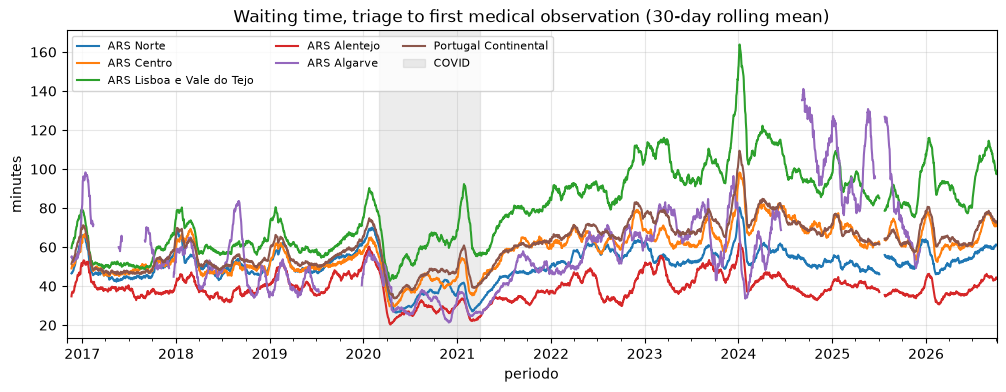

In [4]:
ax = wait.rolling(30, min_periods=20).mean().plot(title="Waiting time, triage to first medical observation (30-day rolling mean)")
ax.set_ylabel("minutes")
ax.axvspan("2020-03-01", "2021-03-31", color="grey", alpha=0.15, label="COVID")
ax.legend(ncol=3, fontsize=8);

In [5]:
yearly = daily.assign(year=daily["periodo"].dt.year).pivot_table(index="year", columns="ars", values="wait_minutes")[REGIONS]
yearly

ars,ARS Norte,ARS Centro,ARS Lisboa e Vale do Tejo,ARS Alentejo,ARS Algarve,Portugal Continental
year,,,,,,
2016,57.2,56.9,71.4,44.7,65.8,62.1
2017,48.3,50.1,55.1,38.4,61.0,50.8
2018,49.8,51.7,62.5,38.1,51.3,54.2
2019,53.6,52.9,63.6,43.6,42.5,56.6
2020,40.0,42.9,61.7,31.8,35.1,47.7
2021,42.4,54.5,74.1,31.9,41.0,55.4
2022,57.6,65.1,92.7,40.4,59.4,69.9
2023,55.9,67.1,106.6,47.0,71.3,74.6
2024,55.4,73.9,104.2,40.3,82.5,74.9


Waiting times rose sharply after COVID: nationally from about 55 minutes (2017–2019) to about 75 (2023–2024), with a slight
improvement since 2025. **Lisboa e Vale do Tejo** is consistently the worst region and the most volatile; **Alentejo** is the
best. The Algarve keeps getting worse, but it is also the noisiest series.

The level shift means that **old years are not representative of the current regime**: a model trained on 2017–2019 levels
will underestimate. Recent data must weigh more, or the model must work on relative changes.

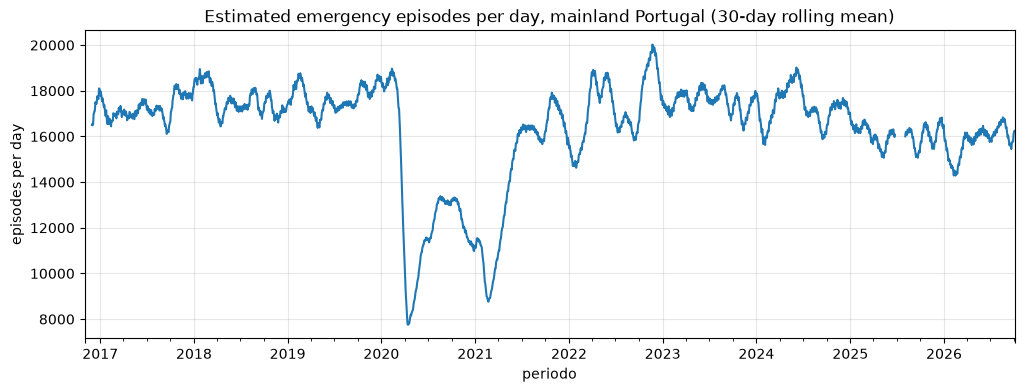

In [6]:
ax = national["episodes"].rolling(30).mean().plot(title="Estimated emergency episodes per day, mainland Portugal (30-day rolling mean)")
ax.set_ylabel("episodes per day");

## 3. Seasonality

,wait_minutes,episodes
Mon,62.3,18014.6
Tue,67.9,17474.2
Wed,64.2,16989.6
Thu,62.3,16713.3
Fri,61.8,16277.0
Sat,58.9,14958.6
Sun,53.9,14430.2


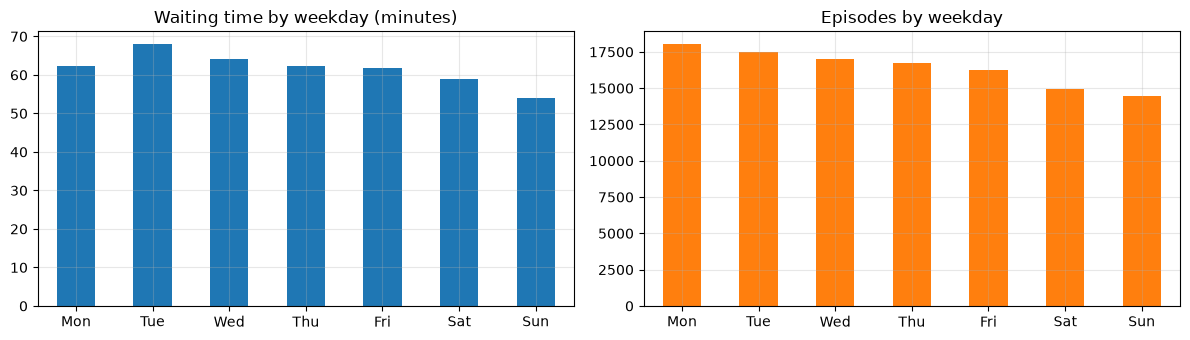

In [7]:
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_weekday = national.groupby(national.index.dayofweek)[["wait_minutes", "episodes"]].mean()
by_weekday.index = weekday_names

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
by_weekday["wait_minutes"].plot.bar(ax=axes[0], title="Waiting time by weekday (minutes)", rot=0)
by_weekday["episodes"].plot.bar(ax=axes[1], title="Episodes by weekday", rot=0, color="tab:orange")
plt.tight_layout()
by_weekday

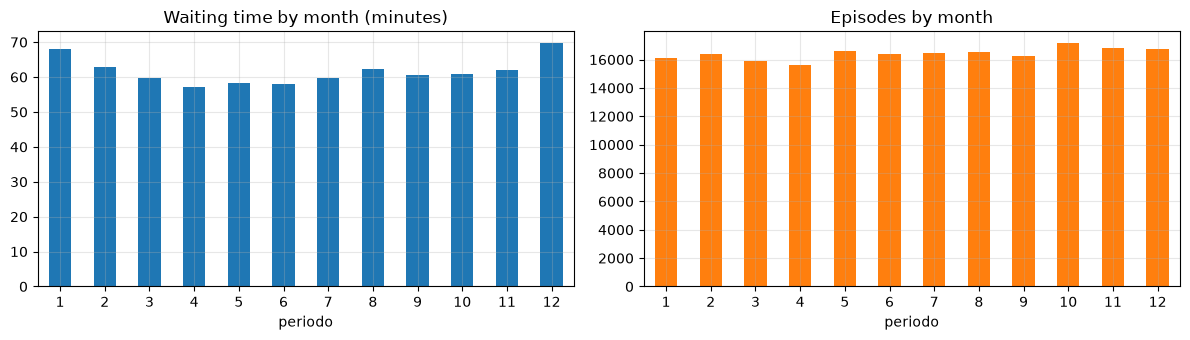

In [8]:
by_month = national.groupby(national.index.month)[["wait_minutes", "episodes"]].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
by_month["wait_minutes"].plot.bar(ax=axes[0], title="Waiting time by month (minutes)", rot=0)
by_month["episodes"].plot.bar(ax=axes[1], title="Episodes by month", rot=0, color="tab:orange")
plt.tight_layout()

In [9]:
pt_holidays = pd.to_datetime(list(holidays.PT(years=range(2016, 2027)).keys()))
weekdays = national[national.index.dayofweek < 5].copy()
weekdays["day_type"] = "regular weekday"
weekdays.loc[weekdays.index.isin(pt_holidays + pd.Timedelta(days=1)), "day_type"] = "day after a holiday"
weekdays.loc[weekdays.index.isin(pt_holidays), "day_type"] = "holiday"
weekdays.groupby("day_type")[["wait_minutes", "episodes"]].mean()

,wait_minutes,episodes
day_type,,
day after a holiday,67.7,18053.2
holiday,58.6,15236.8
regular weekday,63.8,17128.2


In [10]:
christmas = national[
    ((national.index.month == 12) & (national.index.day >= 24)) | ((national.index.month == 1) & (national.index.day <= 5))
]
print(f"Average waiting time 24 Dec–5 Jan: {christmas['wait_minutes'].mean():.1f} min, vs {national['wait_minutes'].mean():.1f} min overall")
national["wait_minutes"].nlargest(5)

Average waiting time 24 Dec–5 Jan: 80.3 min, vs 61.6 min overall


periodo
2023-12-27    161.4
2024-01-03    147.3
2023-12-28    139.2
2024-01-04    138.7
2024-01-02    136.7
Name: wait_minutes, dtype: float64

- **Weekday:** Monday has the most episodes and Tuesday the longest waits; Sunday is the calmest day on both counts.
  The waiting time peaks one day after the demand peak.
- **Month:** December and January are clearly the worst months for waiting time, while the number of episodes barely changes
  across the year. In winter there are not many more patients, but they wait longer.
- **Holidays** behave like a Sunday (fewer episodes, shorter waits), and the **day after** a holiday is worse than a regular weekday.
- **Christmas–New Year** (24 Dec to 5 Jan) averages about 80 minutes nationally; the five worst days on record are all in that window.

## 4. Flu and temperature

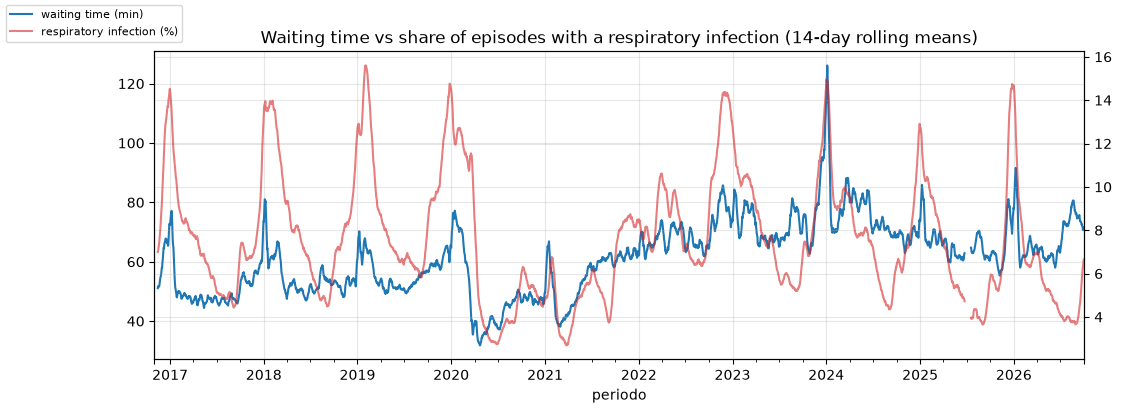

In [11]:
fig, ax1 = plt.subplots()
national["wait_minutes"].rolling(14).mean().plot(ax=ax1, label="waiting time (min)")
ax2 = ax1.twinx()
national["respiratory_pct"].rolling(14).mean().plot(ax=ax2, color="tab:red", alpha=0.6, label="respiratory infection (%)")
ax1.set_title("Waiting time vs share of episodes with a respiratory infection (14-day rolling means)")
fig.legend(loc="upper left", fontsize=8);

In [12]:
columns = ["episodes", "respiratory_pct", "non_urgent_rate", "admission_pct"]
national[["wait_minutes", *columns]].corr()["wait_minutes"].drop("wait_minutes").to_frame("correlation with waiting time")

,correlation with waiting time
episodes,5.6e-01
respiratory_pct,3.7e-01
non_urgent_rate,2.7e-02
admission_pct,-3.1e-01


In [13]:
pd.DataFrame({
    lag: {
        "waiting time": national["wait_minutes"].corr(national["respiratory_pct"].shift(lag)),
        "episodes": national["episodes"].corr(national["respiratory_pct"].shift(lag)),
    }
    for lag in [0, 3, 7, 14]
}).rename_axis(columns="respiratory % lagged by (days)")

respiratory % lagged by (days),0,3,7,14
waiting time,0.4,0.4,0.4,0.3
episodes,0.4,0.4,0.3,0.3


In [14]:
lisboa = daily[daily["ars"] == "ARS Lisboa e Vale do Tejo"].copy()
lisboa["max_temp_band"] = pd.cut(lisboa["temperature_2m_max"], [-50, 15, 20, 25, 30, 35, 60])
print("Correlation of mean temperature with respiratory %:", round(lisboa["temperature_2m_mean"].corr(lisboa["respiratory_pct"]), 2))
lisboa.groupby("max_temp_band", observed=True).agg(days=("wait_minutes", "count"), wait_minutes=("wait_minutes", "mean"), respiratory_pct=("respiratory_pct", "mean"))

Correlation of mean temperature with respiratory %: -0.55


,days,wait_minutes,respiratory_pct
max_temp_band,,,
"(-50, 15]",451,83.5,11.0
"(15, 20]",1251,81.8,9.6
"(20, 25]",844,75.6,7.2
"(25, 30]",733,79.3,6.3
"(30, 35]",284,79.6,5.9
"(35, 60]",50,84.4,5.5


- The share of **respiratory infections** correlates with waiting time (about 0.37) and with episodes. The effect is
  strongest on the same day and fades slowly with lag, so it is a useful *current-state* feature, but at prediction time it
  is only known up to today and can only be used as a lag.
- **Temperature** has almost no linear correlation with waiting time, but the relation is a mild U: in Lisboa, days with a
  maximum below 15 °C average about 83 minutes, mild days (20–25 °C) about 76, and the rare very hot days (≥ 35 °C, 50 days)
  about 84. Cold is tied to respiratory infections (correlation about −0.55), so the two features overlap.
  Tree-based models handle this non-linearity naturally.
- Waiting time correlates with episodes (0.56) but not with the share of non-urgent visits: **long waits come from
  volume and severity, not from people going to the emergency room without needing to.**

## 5. COVID (2020–2021)

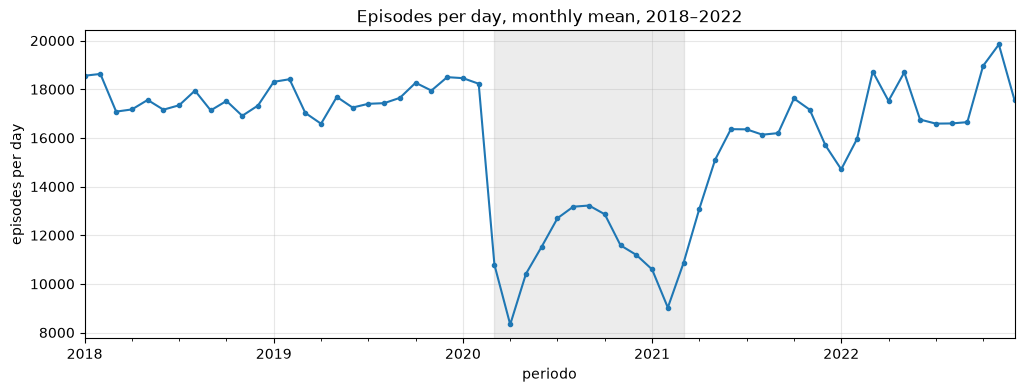

In [15]:
monthly = national["episodes"].resample("MS").mean()
ax = monthly["2018":"2022"].plot(marker=".", title="Episodes per day, monthly mean, 2018–2022")
ax.axvspan("2020-03-01", "2021-03-31", color="grey", alpha=0.15)
ax.set_ylabel("episodes per day");

In [16]:
pd.DataFrame({
    "episodes per day": [national.loc["2019-03":"2019-06", "episodes"].mean(), national.loc["2020-03":"2020-06", "episodes"].mean()],
    "waiting time (min)": [national.loc["2019-03":"2019-06", "wait_minutes"].mean(), national.loc["2020-03":"2020-06", "wait_minutes"].mean()],
}, index=["Mar–Jun 2019", "Mar–Jun 2020"])

,episodes per day,waiting time (min)
Mar–Jun 2019,17139.7,51.6
Mar–Jun 2020,10270.1,38.5


Episodes dropped by about 40 % in March–June 2020 and only recovered to pre-pandemic levels in 2022. Waiting times dropped too.
This period behaves like a different system, so it should not be used as-is to learn normal seasonality.
The chosen handling is recorded as D6 in `docs/decisions.md`.

## 6. Predictability and naive baselines

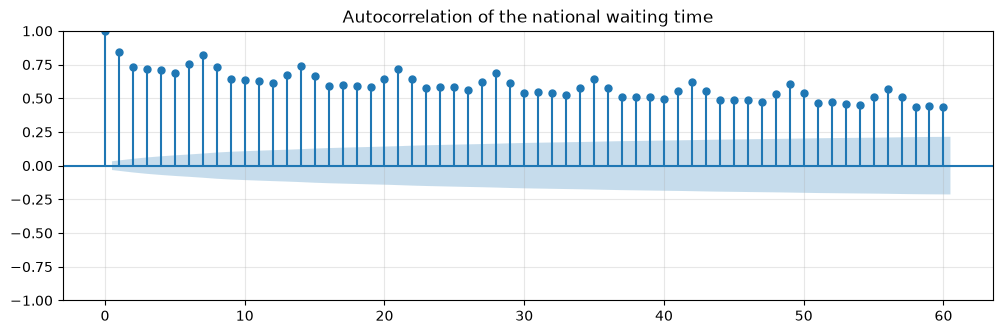

In [17]:
fig, ax = plt.subplots(figsize=(12, 3.5))
plot_acf(national["wait_minutes"].interpolate(), lags=60, ax=ax, title="Autocorrelation of the national waiting time");

In [18]:
def naive_mae(series: pd.Series, lag: int) -> float:
    series = series.asfreq("D")
    return (series - series.shift(lag)).abs()["2024":].mean()

pd.DataFrame({
    "naive: yesterday": {region: naive_mae(wait[region], 1) for region in REGIONS},
    "naive: same weekday last week": {region: naive_mae(wait[region], 7) for region in REGIONS},
    "std. deviation": {region: wait[region]["2024":].std() for region in REGIONS},
}).rename_axis("MAE since 2024, minutes")

,naive: yesterday,naive: same weekday last week,std. deviation
"MAE since 2024, minutes",,,
ARS Norte,6.6,5.9,9.0
ARS Centro,8.6,8.6,12.7
ARS Lisboa e Vale do Tejo,11.0,13.4,19.1
ARS Alentejo,7.1,6.5,8.3
ARS Algarve,29.2,31.4,41.0
Portugal Continental,6.5,6.6,11.1


The series is strongly autocorrelated (0.84 at 1 day, 0.82 at 7 days, with a visible weekly pattern), so naive forecasts are
already decent. These numbers are **the bar every model has to beat** (D2): about 6–7 minutes nationally, 6 in the Norte,
11–13 in Lisboa e Vale do Tejo, and about 30 in the Algarve, whose noise makes it a poor target.

## Key findings

1. **Data quality:** all regions share an 11-day gap (2025-06-24 to 2025-07-04). The **Algarve waiting time is unreliable**:
   large gaps, extreme outliers (up to 378 minutes) and almost no data in 2026. It should not be a modelling target for now (D7).
2. **Regime change:** the national average went from 54 minutes (2017–2019) to 71 (2022 onwards), about 30 % higher. Recent years must weigh more.
3. **Weekly pattern:** Monday has the most episodes, Tuesday the longest waits, Sunday is the calmest day. Holidays behave like
   Sundays and the day after a holiday is worse than a regular weekday.
4. **Winter, not volume, drives waits:** December–January have the longest waits with almost the same number of episodes.
   The Christmas–New Year window is the worst of the year.
5. **Flu matters, non-urgent visits do not:** respiratory infections correlate with waiting time; the share of green/blue
   triage does not.
6. **Temperature is non-linear and weak:** cold and very hot days are slightly worse than mild ones, and cold overlaps with flu.
   Use tree-based models or temperature bands, and expect a small gain.
7. **COVID (2020–2021) is a different system:** episodes dropped by 40 %. Handle it explicitly (D6).
8. **Baseline to beat:** naive MAE of about 6–7 minutes nationally and 11–13 minutes in Lisboa e Vale do Tejo.